# Titanic
Suited for binary logistic regression

In [ ]:
# Necessary libraries for data manipulation and visualization
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Necessary libraries of scikit-learn for machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Download latest version
path = kagglehub.dataset_download("heptapod/titanic")

print("Path to dataset files:", path)

Path to dataset files: /home/rifat/.cache/kagglehub/datasets/heptapod/titanic/versions/1


In [ ]:
df = pd.read_csv('/Logistic_Regression/datasets/train_and_test2.csv')
df.sample(5)

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
702,703,18.0,14.4542,1,0,0,0,0,0,0,...,0,0,0,3,0,0,0.0,0,0,0
858,859,24.0,19.2583,1,0,0,0,0,0,0,...,0,0,0,3,0,0,0.0,0,0,1
1008,1009,1.0,16.7000,1,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1243,1244,18.0,73.5000,0,0,0,0,0,0,0,...,0,0,0,2,0,0,2.0,0,0,0
1291,1292,30.0,164.8667,1,0,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,0


### Exploratory Data Analysis

In [ ]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.13      1309

In [ ]:
# Check for columns with only one unique value
zero_cols = [c for c in df.columns if df[c].nunique() == 1]
cols_to_drop = zero_cols + [c for c in df.columns if c == 'Passengerid']

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(df)

       Age      Fare  Sex  sibsp  Parch  Pclass  Embarked  2urvived
0     22.0    7.2500    0      1      0       3       2.0         0
1     38.0   71.2833    1      1      0       1       0.0         1
2     26.0    7.9250    1      0      0       3       2.0         1
3     35.0   53.1000    1      1      0       1       2.0         1
4     35.0    8.0500    0      0      0       3       2.0         0
...    ...       ...  ...    ...    ...     ...       ...       ...
1304  28.0    8.0500    0      0      0       3       2.0         0
1305  39.0  108.9000    1      0      0       1       0.0         0
1306  38.5    7.2500    0      0      0       3       2.0         0
1307  28.0    8.0500    0      0      0       3       2.0         0
1308  28.0   22.3583    0      1      1       3       0.0         0

[1309 rows x 8 columns]


In [ ]:
df.rename(columns={'2urvived': 'Survived', 'sibsp': 'siblings_spouses', 'Parch': 'parents_children', 'Pclass': 'Passenger_Class'}, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1309 non-null   float64
 1   Fare              1309 non-null   float64
 2   Sex               1309 non-null   int64  
 3   siblings_spouses  1309 non-null   int64  
 4   parents_children  1309 non-null   int64  
 5   Passenger_Class   1309 non-null   int64  
 6   Embarked          1307 non-null   float64
 7   Survived          1309 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 81.9 KB


In [ ]:
for c in df.columns:
    print(f"Column: {c}, Unique Values: {df[c].nunique()}")

Column: Age, Unique Values: 98
Column: Fare, Unique Values: 281
Column: Sex, Unique Values: 2
Column: siblings_spouses, Unique Values: 7
Column: parents_children, Unique Values: 8
Column: Passenger_Class, Unique Values: 3
Column: Embarked, Unique Values: 3
Column: Survived, Unique Values: 2


In [ ]:
correlation = df.corr()['Survived'].sort_values(ascending=False)
print(correlation)

Survived            1.000000
Sex                 0.404020
Fare                0.173786
parents_children    0.054908
siblings_spouses   -0.014375
Age                -0.055862
Embarked           -0.093225
Passenger_Class    -0.244686
Name: Survived, dtype: float64


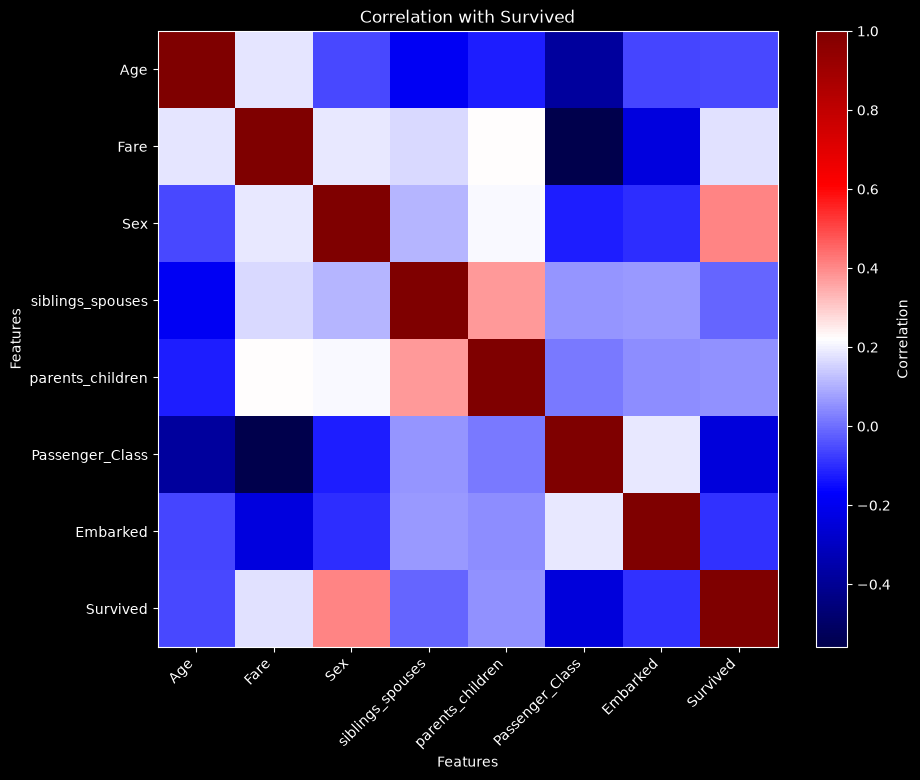

In [ ]:
# Correlation visualization using matplotlib
plt.style.use('dark_background')

plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
plt.imshow(corr_matrix, cmap='seismic', aspect='auto')

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.colorbar(label='Correlation')
plt.title('Correlation with Survived')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

### Train Test Split

In [ ]:

X = df.drop('Survived', axis=1)
y = df['Survived']

In [ ]:
# Check for missing values in the features or null
print(X.isnull().sum())

Age                 0
Fare                0
Sex                 0
siblings_spouses    0
parents_children    0
Passenger_Class     0
Embarked            2
dtype: int64


In [ ]:
# Fill missing values in the 'Embarked' column with 0
X.loc[X['Embarked'].isnull(), 'Embarked'] = 0
X['Embarked'].isnull().sum()

np.int64(0)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [ ]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(1047, 7) (262, 7) (1047,) (262,)


### Feature Scaling

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
# Coefficients and intercept of the logistic regression model
print(f"Coefficients: \n{model.coef_}\n\nIntercept: {model.intercept_}")

Coefficients: 
[[-2.60519613e-02 -5.08646058e-05  1.84884779e+00 -1.85399925e-01
  -4.86062754e-02 -7.50662373e-01 -7.79219418e-02]]

Intercept: [0.72505334]


### Prediction

In [ ]:
# Predicting the target variable for the test set
y_pred = model.predict(X_test)
print(f"Predicted values: {y_pred}")

Predicted values: [0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1
 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 1 1]


In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.4f}")
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.4f}")

Accuracy: 0.7672
Mean Squared Error: 0.2328
Mean Absolute Error: 0.2328
R-squared: -0.1584
